# **Semana 3: Redes Neuronales Convolucionales**

Este cuaderno contiene explicaciones detalladas y código práctico para comprender el funcionamiento de las Redes Neuronales Convolucionales (CNN) y su aplicación en tareas de Visión Artificial, incluyendo convolución manual, submuestreo, entrenamiento desde cero en PyTorch, uso de PyTorch Lightning y transferencia de aprendizaje (Transfer Learning) con ResNet18.

In [40]:
# ============================================================
# Instalación de dependencias (para entornos tipo Google Colab)
# ============================================================
!pip install -q pytorch-lightning torchview

In [41]:
# ============================================================
# Importación Consolidada de Librerías
# ============================================================
import sys
import os
import gc
import urllib.request
import zipfile
import warnings
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
import cv2
import skimage.measure as sm
import graphviz

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchmetrics.classification import F1Score
from torchview import draw_graph

import pytorch_lightning as pl
from pytorch_lightning import Trainer, seed_everything
from pytorch_lightning.callbacks import ModelCheckpoint

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, f1_score
from tqdm.notebook import tqdm

# --- Configuración inicial ---
warnings.filterwarnings("ignore")
graphviz.set_jupyter_format('png')

'png'

In [42]:
# ============================================================
# Configuración del Dispositivo de Cómputo (GPU/CPU)
# ============================================================
in_colab = 'google.colab' in sys.modules
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "Ninguna (CPU)"

print(f"¿Entorno Google Colab?: {in_colab}")
print(f"Dispositivo activo: {device}")
print(f"GPU asignada: {gpu_name}")

¿Entorno Google Colab?: True
Dispositivo activo: cuda
GPU asignada: Tesla T4


# **1. Introducción a la Convolución**

La convolución es una operación matemática básica en procesamiento de imágenes y visión por computadora. Consiste en deslizar una ventana pequeña de coeficientes (llamada **filtro** o **kernel**) sobre una imagen, realizando la suma del producto elemento a elemento, para generar un nuevo mapa de características de la imagen de entrada.

## **1.1 Banco de Filtros Leung-Malik (LM)**

El banco de filtros de Leung-Malik (LM) consta de 48 filtros a múltiples escalas y orientaciones, diseñados para capturar texturas, bordes y manchas en imágenes. Está compuesto por:
*   **18 filtros de primera derivada de Gaussiana** (detectores de bordes).
*   **18 filtros de segunda derivada de Gaussiana** (detectores de barras y líneas).
*   **8 filtros Laplacian of Gaussian (LoG)** (detectores de blobs/manchas).
*   **4 filtros Gaussianos simples** (suavizado).

In [43]:
# ============================================================
# Definición de las funciones matemáticas del banco de filtros LM
# ============================================================
def gaussian1d(sigma, mean, x, ord):
    """Calcula la Gaussiana unidimensional y sus derivadas de 1er y 2do orden."""
    x = np.array(x)
    x_ = x - mean
    var = sigma**2
    g1 = (1/np.sqrt(2*np.pi*var))*(np.exp((-1*x_*x_)/(2*var)))

    if ord == 0:
        return g1
    elif ord == 1:
        return -g1*((x_)/(var))
    else:
        return g1*(((x_*x_) - var)/(var**2))

def gaussian2d(sup, scales):
    """Genera una Gaussiana 2D simétrica de tamaño (sup x sup)."""
    var = scales * scales
    shape = (sup, sup)
    n, m = [(i - 1)/2 for i in shape]
    x, y = np.ogrid[-m:m+1, -n:n+1]
    g = (1/np.sqrt(2*np.pi*var))*np.exp( -(x*x + y*y) / (2*var) )
    return g

def log2d(sup, scales):
    """Genera un filtro Laplaciano de Gaussiana (LoG) 2D."""
    var = scales * scales
    shape = (sup, sup)
    n, m = [(i - 1)/2 for i in shape]
    x, y = np.ogrid[-m:m+1, -n:n+1]
    g = (1/np.sqrt(2*np.pi*var))*np.exp( -(x*x + y*y) / (2*var) )
    h = g*((x*x + y*y) - var)/(var**2)
    return h

def makefilter(scale, phasex, phasey, pts, sup):
    """Combina componentes Gaussianas 1D en orientaciones específicas para formar un kernel 2D."""
    gx = gaussian1d(3*scale, 0, pts[0,...], phasex)
    gy = gaussian1d(scale,   0, pts[1,...], phasey)
    image = gx*gy
    image = np.reshape(image, (sup, sup))
    return image

def makeLMfilters():
    """Construye el banco completo de 48 filtros Leung-Malik (LM)."""
    sup     = 49
    scalex  = np.sqrt(2) * np.array([1, 2, 3])
    norient = 6
    nrotinv = 12

    nbar  = len(scalex)*norient
    nedge = len(scalex)*norient
    nf    = nbar+nedge+nrotinv
    F     = np.zeros([sup, sup, nf])
    hsup  = (sup - 1)/2

    x = [np.arange(-hsup, hsup+1)]
    y = [np.arange(-hsup, hsup+1)]
    [x, y] = np.meshgrid(x, y)

    orgpts = [x.flatten(), y.flatten()]
    orgpts = np.array(orgpts)

    count = 0
    for scale in range(len(scalex)):
        for orient in range(norient):
            angle = (np.pi * orient)/norient
            c = np.cos(angle)
            s = np.sin(angle)
            rotpts = [[c+0, -s+0], [s+0, c+0]]
            rotpts = np.array(rotpts)
            rotpts = np.dot(rotpts, orgpts)
            F[:,:,count] = makefilter(scalex[scale], 0, 1, rotpts, sup)
            F[:,:,count+nedge] = makefilter(scalex[scale], 0, 2, rotpts, sup)
            count = count + 1

    count = nbar+nedge
    scales = np.sqrt(2) * np.array([1, 2, 3, 4])

    for i in range(len(scales)):
        F[:,:,count]   = gaussian2d(sup, scales[i])
        count = count + 1

    for i in range(len(scales)):
        F[:,:,count] = log2d(sup, scales[i])
        count = count + 1

    for i in range(len(scales)):
        F[:,:,count] = log2d(sup, 3*scales[i])
        count = count + 1

    return F

In [44]:
F = makeLMfilters()
print(f"Dimensiones de la matriz de filtros (H, W, cantidad): {F.shape}")

Dimensiones de la matriz de filtros (H, W, cantidad): (49, 49, 48)


### **1.1.1 Filtros de Primera Derivada Gaussiana (Bordes)**

Estos 18 filtros actúan como detectores de bordes en diferentes direcciones (orientaciones) y escalas.

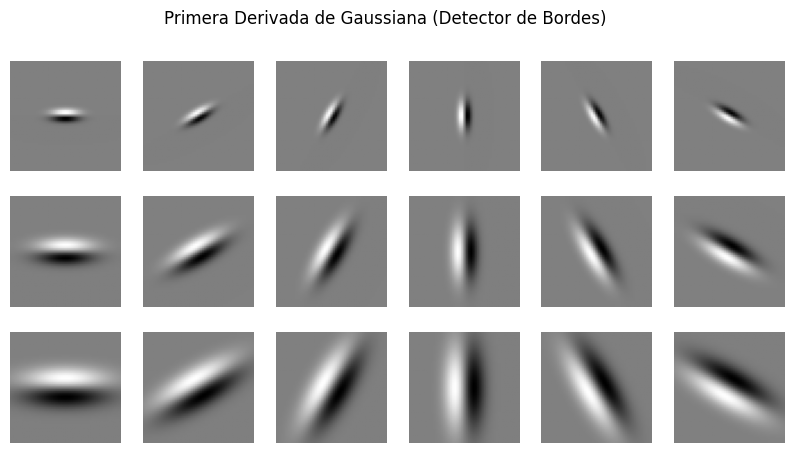

In [45]:
plt.figure(figsize=(10, 5))
for i in range(0, 18):
    plt.subplot(3, 6, i+1)
    plt.axis('off')
    plt.imshow(F[:,:,i], cmap='gray')
plt.suptitle("Primera Derivada de Gaussiana (Detector de Bordes)")
plt.show()

### **1.1.2 Filtros de Segunda Derivada Gaussiana (Barras y Líneas)**

Estos 18 filtros son sensibles a estructuras filamentosas (líneas finas o barras) en distintas escalas y ángulos.

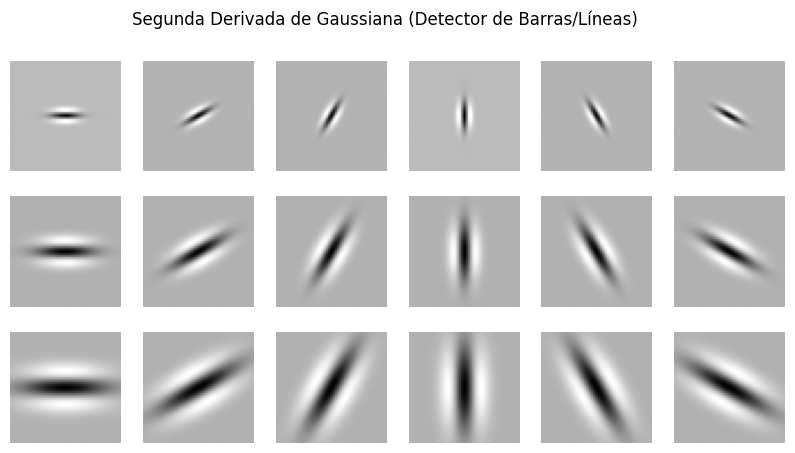

In [46]:
plt.figure(figsize=(10, 5))
for i in range(0, 18):
    plt.subplot(3, 6, i+1)
    plt.axis('off')
    plt.imshow(F[:,:,i+18], cmap='gray')
plt.suptitle("Segunda Derivada de Gaussiana (Detector de Barras/Líneas)")
plt.show()

### **1.1.3 Filtros Laplacian of Gaussian (LoG) y Gaussianas Simples (Manchas/Blobs)**

Los últimos 12 filtros detectan manchas circulares de alta frecuencia (LoG) y aplican suavizado uniforme (Gaussiana simple).

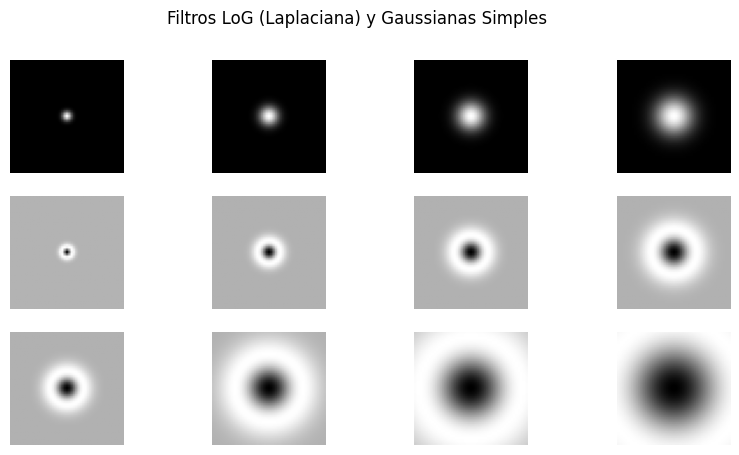

In [47]:
plt.figure(figsize=(10, 5))
for i in range(0, 12):
    plt.subplot(3, 4, i+1)
    plt.axis('off')
    plt.imshow(F[:,:,i+36], cmap='gray')
plt.suptitle("Filtros LoG (Laplaciana) y Gaussianas Simples")
plt.show()

## **1.2 Aplicación de Filtros en una Imagen de Prueba**

Aplicaremos el banco de filtros LM sobre una imagen de prueba mediante la convolución 2D de OpenCV (`cv2.filter2D`) para observar las características que cada filtro extrae de la imagen.

In [48]:
# ============================================================
# Funciones auxiliares para mostrar imágenes y aplicar filtros
# ============================================================
def mostrar_imagen(img, titulo):
    """Muestra una única imagen usando matplotlib."""
    plt.axis('off')
    plt.imshow(img)
    plt.title(titulo)
    plt.show()

def aplicar_banco_filtros(imagen, filtros):
    """Aplica el banco completo de 48 filtros sobre la imagen y dibuja la cuadrícula."""
    imagen_gris = cv2.cvtColor(imagen, cv2.COLOR_RGB2GRAY)
    plt.figure(figsize=(20, 25))
    for i in range(48):
        # Realizar convolución 2D usando el kernel F[:,:,i]
        imagen_conv = cv2.filter2D(imagen_gris, -1, filtros[:,:,i])
        # Aplicar activación lineal rectificada (ReLU) manual para visualizar activaciones positivas
        imagen_conv = np.maximum(imagen_conv, 0)
        plt.subplot(6, 8, i+1)
        plt.axis('off')
        plt.imshow(imagen_conv, cmap='gray')
    plt.suptitle("Resultado de Convoluciones con el Banco LM", fontsize=20)
    plt.show()

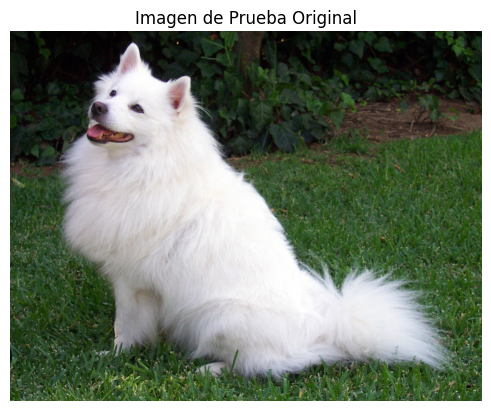

In [49]:
# ============================================================
# Descarga y carga de la imagen de prueba
# ============================================================
img_url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
img_path = "Imagen1.jpg"

if not os.path.exists(img_path):
    print("Descargando imagen de prueba...")
    urllib.request.urlretrieve(img_url, img_path)

imagen_prueba = cv2.imread(img_path)
imagen_prueba = cv2.cvtColor(imagen_prueba, cv2.COLOR_BGR2RGB)
mostrar_imagen(imagen_prueba, "Imagen de Prueba Original")

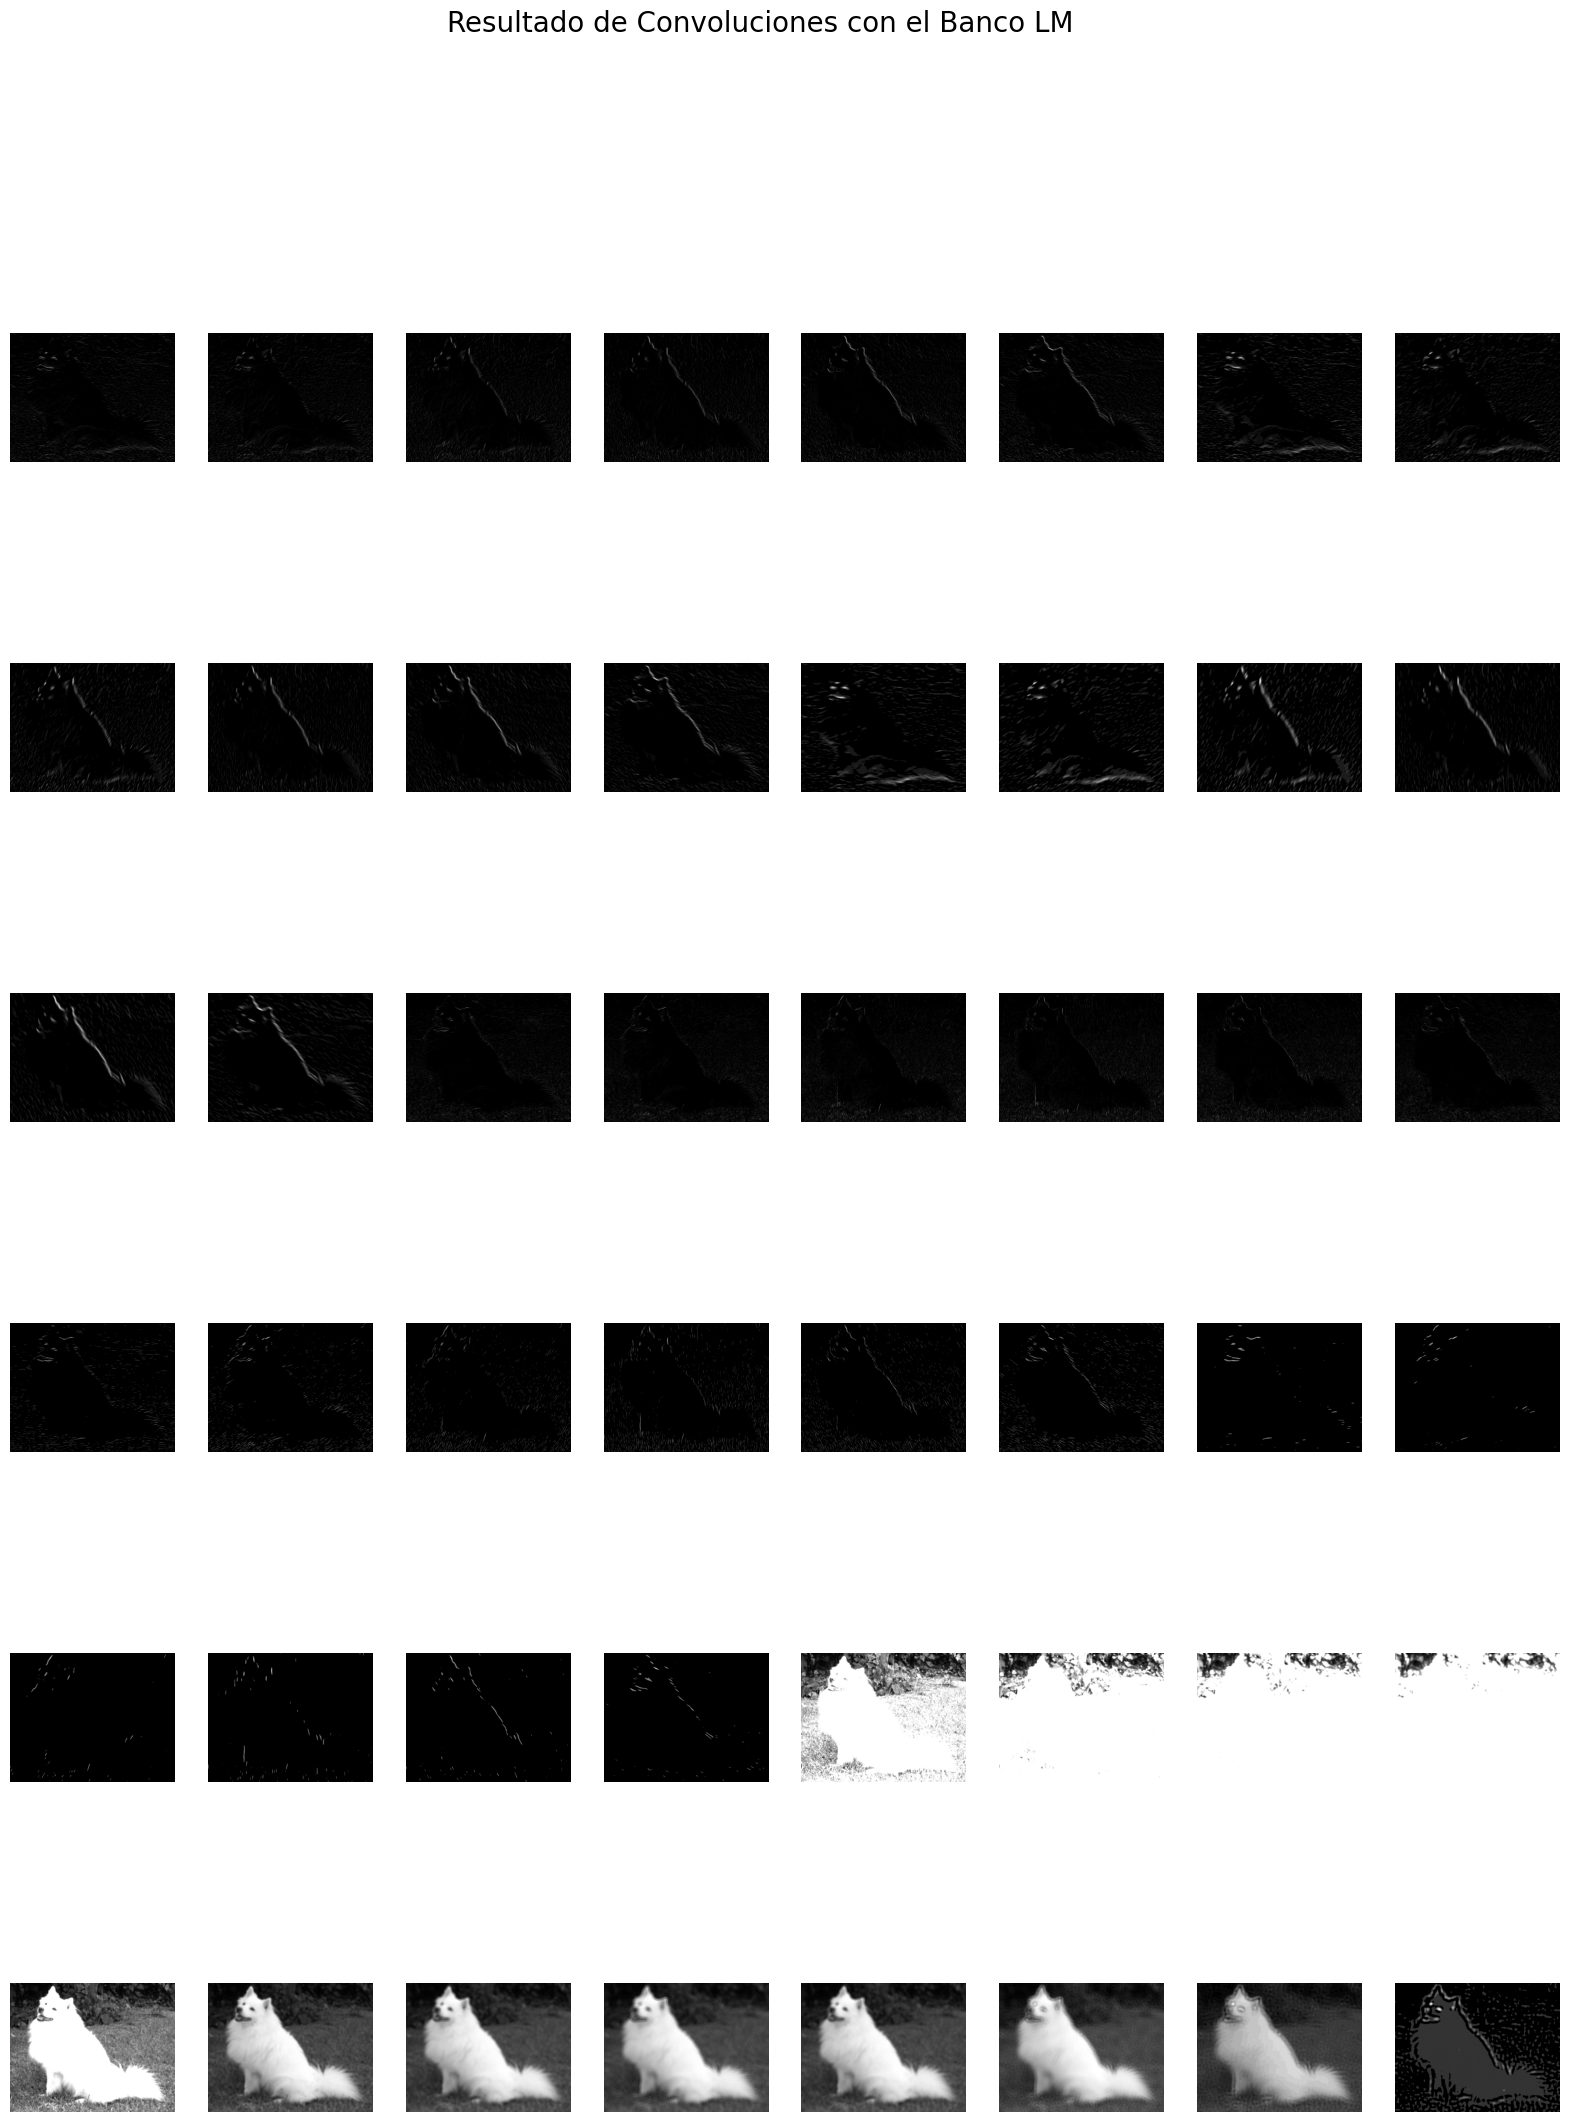

In [50]:
# Aplicar el banco completo sobre la imagen de prueba descargada
aplicar_banco_filtros(imagen_prueba, F)

# **2. Operación de Pooling (Submuestreo)**

La operación de pooling (o submuestreo) reduce la resolución espacial de los mapas de características resultantes de las convoluciones. Esto ayuda a:
1.  **Reducir parámetros**: Disminuye el tamaño espacial para las capas FC finales.
2.  **Invarianza a traslaciones**: El pooling preserva la presencia de una característica en una región, incluso si su posición exacta varía ligeramente.
3.  **MaxPooling**: Selecciona el valor máximo de una ventana local (comúnmente de tamaño 2x2, lo que reduce a la mitad el ancho y alto).

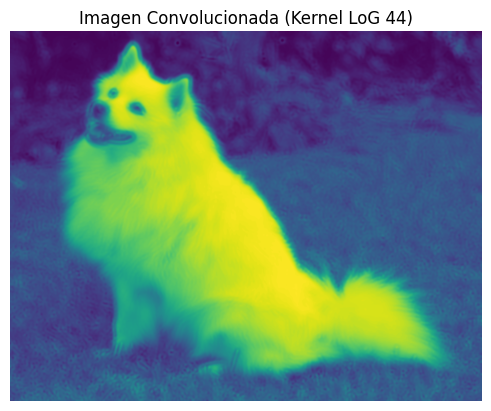

Dimensiones convolucionadas: (1213, 1546)


In [51]:
# ============================================================
# Convolución con un único filtro de textura para el Pooling
# ============================================================
imagen_gris = cv2.cvtColor(imagen_prueba, cv2.COLOR_RGB2GRAY)
# Usaremos el filtro LoG en el índice 44
imagen_conv = cv2.filter2D(imagen_gris, -1, F[:,:,44])
imagen_conv = np.maximum(imagen_conv, 0)

mostrar_imagen(imagen_conv, "Imagen Convolucionada (Kernel LoG 44)")
print(f"Dimensiones convolucionadas: {imagen_conv.shape}")

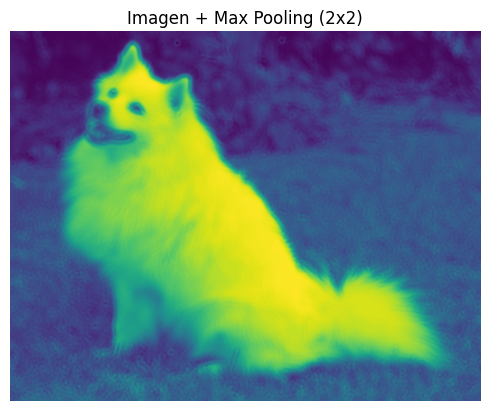

Dimensiones después de Pooling (Reducido a la mitad): (607, 773)


In [52]:
# Aplicar Max Pooling de 2x2 usando block_reduce de skimage
imagen_pool = sm.block_reduce(imagen_conv, (2,2), np.max)
mostrar_imagen(imagen_pool, "Imagen + Max Pooling (2x2)")
print(f"Dimensiones después de Pooling (Reducido a la mitad): {imagen_pool.shape}")

# **3. Caso de Estudio: Clasificación de MNIST con CNN desde Cero**

MNIST es un dataset estándar de clasificación de dígitos escritos a mano (del 0 al 9), que consta de 60,000 imágenes de entrenamiento y 10,000 de prueba. Cada imagen tiene una resolución de 28x28 píxeles en escala de grises.

### **Cálculo de Dimensiones en Capas Convolucionales**

La fórmula matemática para calcular el ancho ($W_{out}$) y el alto ($H_{out}$) del volumen de salida tras una capa convolucional 2D es:

$$O = \lfloor \frac{I - K + 2P}{S} \rfloor + 1$$

Donde:
*   $I$: Dimensión de entrada (ancho o alto).
*   $K$: Tamaño del kernel (filtro).
*   $P$: Relleno (*padding*).
*   $S$: Desplazamiento (*stride*).
*   $\lfloor \cdot \rfloor$: Redondeo hacia abajo (función piso).

El submuestreo MaxPool2d de tamaño 2x2 reduce las dimensiones dividiéndolas entre 2 (ej. $14 \rightarrow 7$).

## **3.1 Carga del Dataset MNIST**

In [53]:
# ============================================================
# Descarga y normalización del dataset MNIST
# ============================================================
datos_entrenamiento = datasets.MNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    download=True
)

datos_prueba = datasets.MNIST(
    root="data",
    train=False,
    transform=ToTensor(),
    download=True
)

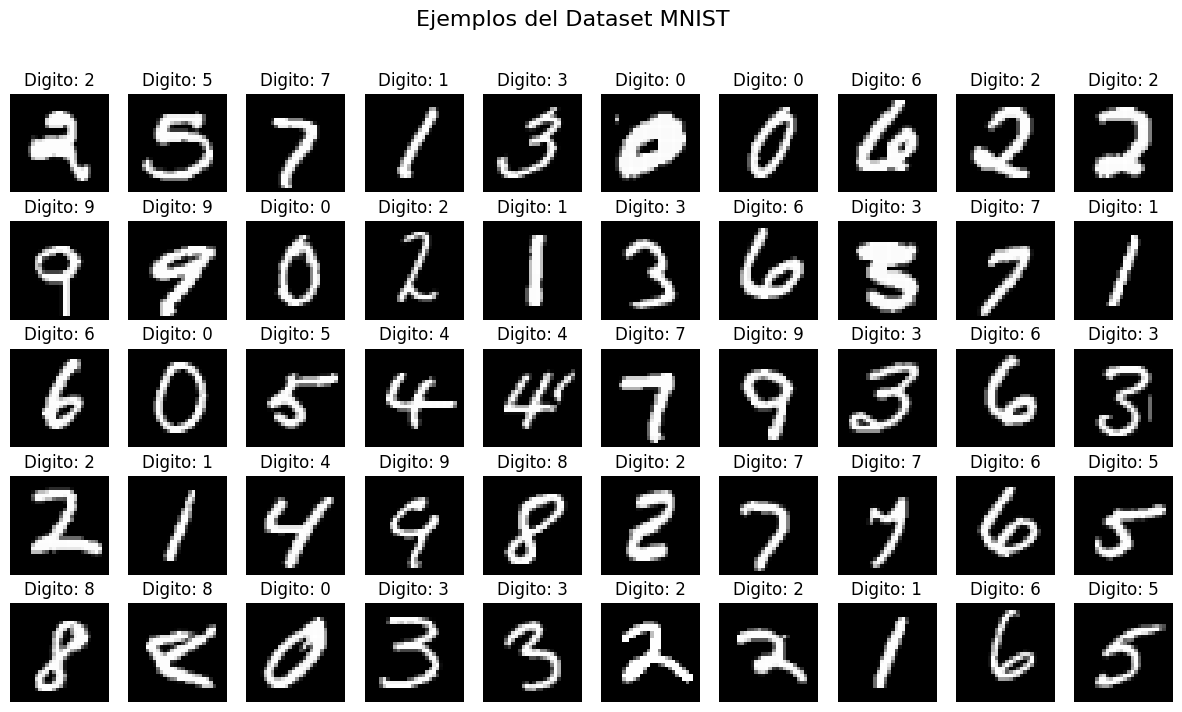

In [54]:
# Mostrar una rejilla con muestras aleatorias del dataset MNIST
fig = plt.figure(figsize=(15, 8))
columnas = 10
filas = 5
for i in range(1, columnas * filas + 1):
    idx = torch.randint(len(datos_entrenamiento), size=(1,)).item()
    img, label = datos_entrenamiento[idx]
    fig.add_subplot(filas, columnas, i)
    plt.title(f"Digito: {label}")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.suptitle("Ejemplos del Dataset MNIST", fontsize=16)
plt.show()

In [55]:
# ============================================================
# Creación de los DataLoaders estructurados en Español
# ============================================================
cargadores_mnist = {
    "entrenamiento": DataLoader(
        datos_entrenamiento,
        batch_size=100,
        shuffle=True,
        num_workers=2
    ),
    "prueba": DataLoader(
        datos_prueba,
        batch_size=100,
        shuffle=False,
        num_workers=2
    )
}

## **3.2 Configuración de Hiperparámetros**

In [56]:
# ============================================================
# Hiperparámetros de entrenamiento del modelo PyTorch base
# ============================================================
num_clases = 10      # Clases de salida (dígitos del 0 al 9)
num_epocas = 10      # Número total de pasadas sobre el dataset
batch_size = 100     # Cantidad de imágenes procesadas por lote
lr = 1e-3            # Tasa de aprendizaje (Learning rate)


## **3.3 Funciones de Entrenamiento y Evaluación en PyTorch**

In [57]:
# ============================================================
# Bucle de Entrenamiento y Evaluación Estándar en PyTorch
# ============================================================
def entrenar_modelo_pytorch(num_epocas, modelo, cargadores, optimizador, funcion_perdida):
    """Entrena el modelo y grafica la curva de pérdida de entrenamiento."""
    modelo.train()
    pasos_totales = len(cargadores["entrenamiento"])
    historial_perdidas = []

    for epoca in range(num_epocas):
        perdida_acumulada = 0.0
        # Envolver el cargador de entrenamiento en una barra de progreso tqdm
        bucle_progreso = tqdm(
            enumerate(cargadores["entrenamiento"]),
            total=pasos_totales,
            desc=f"Época {epoca+1}/{num_epocas}",
            leave=False
        )
        for i, (imagenes, etiquetas) in bucle_progreso:
            optimizador.zero_grad()
            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)
            
            # Forward pass
            salidas = modelo(imagenes)
            perdida = funcion_perdida(salidas, etiquetas)
            
            # Backward y actualización de pesos
            perdida.backward()
            optimizador.step()
            
            perdida_acumulada += perdida.item()
            bucle_progreso.set_postfix(loss=perdida.item())
        
        perdida_epoca = perdida_acumulada / pasos_totales
        historial_perdidas.append(perdida_epoca)
        print(f"Época [{epoca+1}/{num_epocas}] | Pérdida Entrenamiento Promedio: {perdida_epoca:.4f}")

    # Visualización gráfica de la pérdida
    plt.plot(historial_perdidas, color='#4C72B0', marker='o')
    plt.title("Curva de Pérdida de Entrenamiento")
    plt.xlabel("Época")
    plt.ylabel("Pérdida promedio")
    plt.grid(True)
    plt.show()
    return modelo

def evaluar_modelo_pytorch(modelo, cargadores):
    """Evalúa el modelo calculando el F1-Macro en el conjunto de prueba."""
    modelo.eval()
    todas_predicciones = []
    todas_etiquetas = []
    with torch.no_grad():
        for imagenes, etiquetas in cargadores["prueba"]:
            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)
            salidas = modelo(imagenes)
            predicciones = torch.max(salidas, 1)[1]
            todas_predicciones.extend(predicciones.cpu().numpy())
            todas_etiquetas.extend(etiquetas.cpu().numpy())
    
    f1 = f1_score(todas_etiquetas, todas_predicciones, average='macro', zero_division=0)
    print(f"F1-Macro en el conjunto de prueba: {f1:.4f}")


## **3.4 Arquitectura CNN con Cálculo Manual (red_cnn_manual)**

Definiremos una red neuronal convolucional clásica con dos bloques convolucionales. Con padding=2 en la primera capa convolucional de kernel 5x5, el tamaño se conserva en 28x28 antes del pooling.

In [58]:
# ============================================================
# Definición de la red convolucional manual (MNIST)
# ============================================================
class red_cnn_manual(nn.Module):
    def __init__(self):
        super(red_cnn_manual, self).__init__()

        # Bloque 1: entrada 28x28x1
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # Salida: 14x14x16
        )
        
        # Bloque 2: entrada 14x14x16
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # Salida: 7x7x32 (1568 características)
        )
        
        # Capa completamente conectada
        self.fc = nn.Linear(32 * 7 * 7, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        # Aplanar la salida (flatten)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

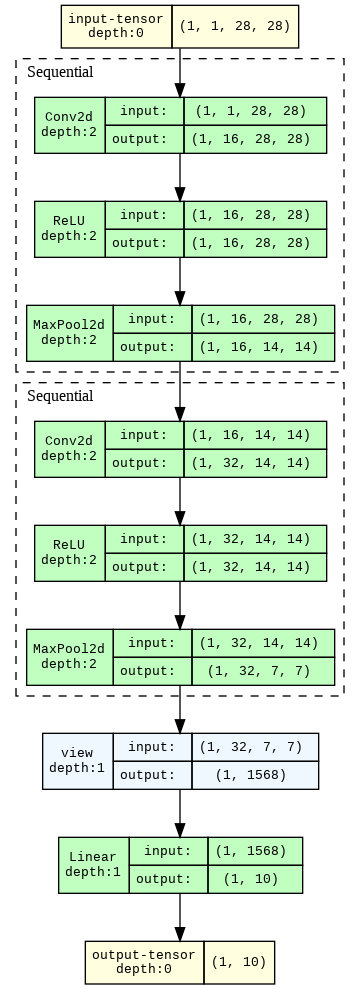

In [59]:
# Graficar el flujo del modelo red_cnn_manual
grafo_manual = draw_graph(red_cnn_manual(), input_size=(1, 1, 28, 28), expand_nested=True)
grafo_manual.visual_graph

Época 1/10:   0%|          | 0/600 [00:00<?, ?it/s]

Época [1/10] | Pérdida Entrenamiento Promedio: 0.2410


Época 2/10:   0%|          | 0/600 [00:00<?, ?it/s]

Época [2/10] | Pérdida Entrenamiento Promedio: 0.0664


Época 3/10:   0%|          | 0/600 [00:00<?, ?it/s]

...

Época [8/10] | Pérdida Entrenamiento Promedio: 0.0195


Época 9/10:   0%|          | 0/600 [00:00<?, ?it/s]

Época [9/10] | Pérdida Entrenamiento Promedio: 0.0168


Época 10/10:   0%|          | 0/600 [00:00<?, ?it/s]

Época [10/10] | Pérdida Entrenamiento Promedio: 0.0151


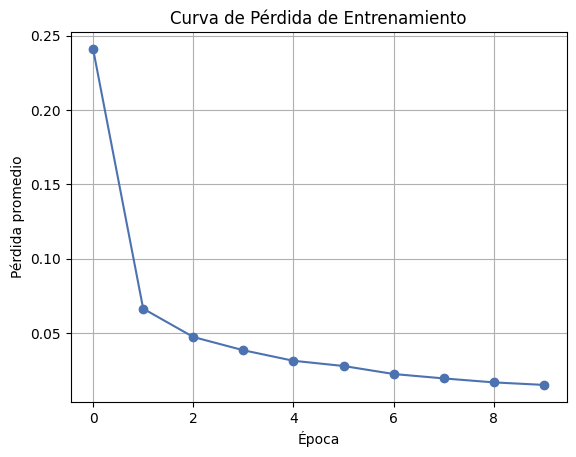

In [60]:
# Inicializar el modelo manual, optimizador y función de costo
modelo_manual = red_cnn_manual().to(device)
criterio = nn.CrossEntropyLoss()
optimizador = optim.Adam(modelo_manual.parameters(), lr=lr)

# Entrenar
modelo_manual = entrenar_modelo_pytorch(num_epocas, modelo_manual, cargadores_mnist, optimizador, criterio)

In [61]:
# Evaluar el modelo manual
evaluar_modelo_pytorch(modelo_manual, cargadores_mnist)

F1-Macro en el conjunto de prueba: 0.9901


## **3.5 Visualización de Características Aprendidas (Kernels)**

Graficaremos los filtros del primer bloque convolucional de la red manual una vez entrenada, para ver qué patrones (bordes, contrastes) ha aprendido a detectar en las imágenes.

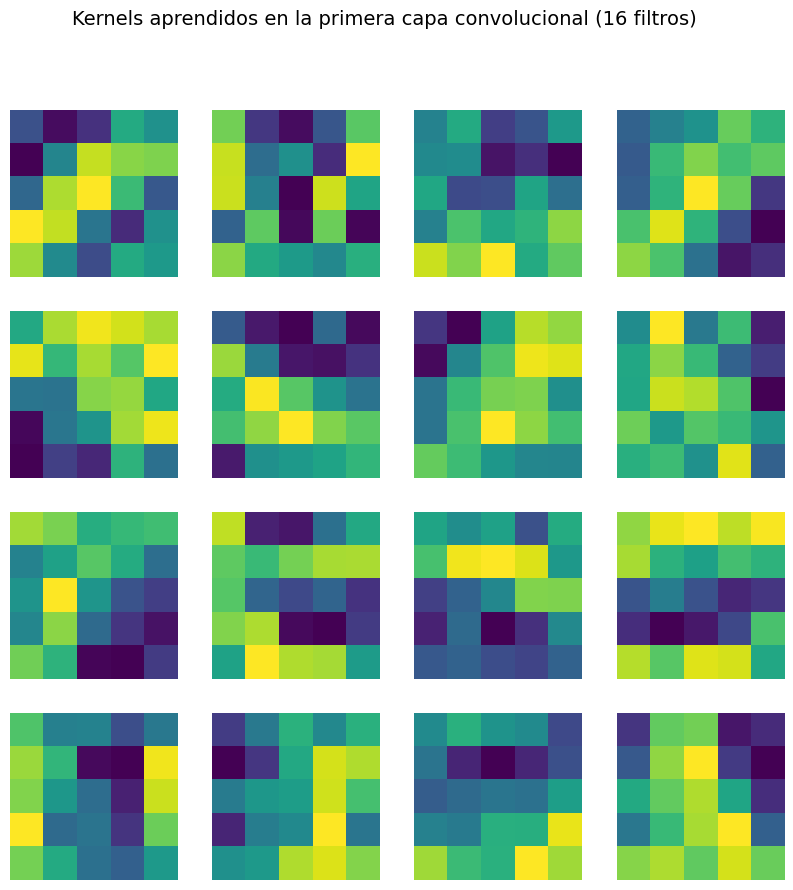

In [62]:
# Extraer pesos del primer conv de red_cnn_manual
kernels_conv1 = modelo_manual.conv1[0].weight.detach().clone().cpu()

# Graficar los 16 kernels
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.axis('off')
    plt.imshow(kernels_conv1[i, 0, :, :], cmap='viridis')
plt.suptitle("Kernels aprendidos en la primera capa convolucional (16 filtros)", fontsize=14)
plt.show()

## **3.6 Arquitectura CNN con Capa Adaptativa (red_cnn_adaptativa)**

Las capas de pooling adaptativo (`AdaptiveMaxPool2d` o `AdaptiveAvgPool2d`) nos permiten definir una salida con dimensiones fijas (como 5x5) sin importar el tamaño espacial de entrada de la imagen. Esto aporta flexibilidad al modelo.

In [63]:
# ============================================================
# Definición de la red convolucional con capa adaptativa
# ============================================================
class red_cnn_adaptativa(nn.Module):
    def __init__(self):
        super(red_cnn_adaptativa, self).__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Forzar que la salida espacial sea de 5x5 en lugar del 7x7 resultante manual
        self.adapt = nn.AdaptiveMaxPool2d((5, 5))
        
        # Total de características de entrada: 32 * 5 * 5 = 800
        self.fc = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.adapt(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

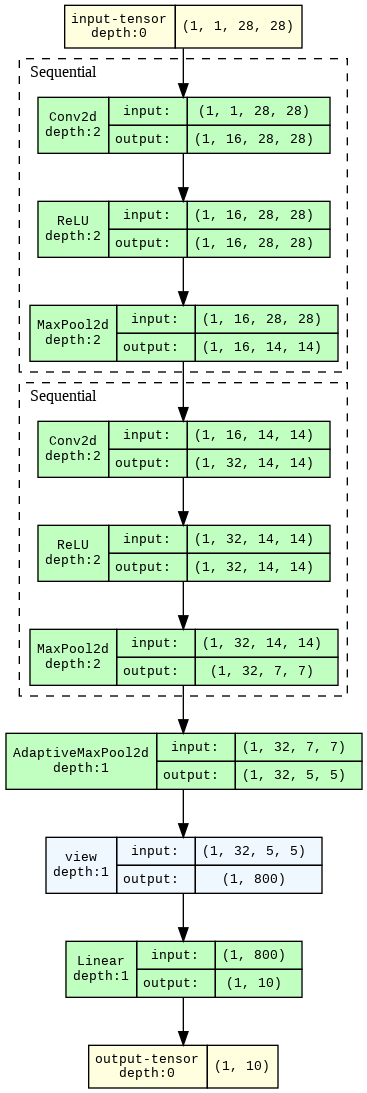

In [64]:
# Graficar el flujo del modelo red_cnn_adaptativa
grafo_adaptativo = draw_graph(red_cnn_adaptativa(), input_size=(1, 1, 28, 28), expand_nested=True)
grafo_adaptativo.visual_graph

Época 1/10:   0%|          | 0/600 [00:00<?, ?it/s]

Época [1/10] | Pérdida Entrenamiento Promedio: 0.2593


Época 2/10:   0%|          | 0/600 [00:00<?, ?it/s]

Época [2/10] | Pérdida Entrenamiento Promedio: 0.0689


Época 3/10:   0%|          | 0/600 [00:00<?, ?it/s]

...

Época [8/10] | Pérdida Entrenamiento Promedio: 0.0218


Época 9/10:   0%|          | 0/600 [00:00<?, ?it/s]

Época [9/10] | Pérdida Entrenamiento Promedio: 0.0199


Época 10/10:   0%|          | 0/600 [00:00<?, ?it/s]

Época [10/10] | Pérdida Entrenamiento Promedio: 0.0176


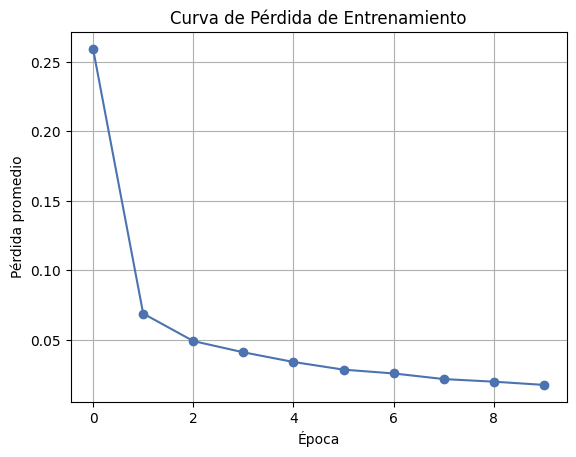

In [65]:
# Inicializar, optimizar y entrenar el modelo adaptativo
modelo_adaptativo = red_cnn_adaptativa().to(device)
optimizador_adaptativo = optim.Adam(modelo_adaptativo.parameters(), lr=lr)

# Entrenar
modelo_adaptativo = entrenar_modelo_pytorch(num_epocas, modelo_adaptativo, cargadores_mnist, optimizador_adaptativo, criterio)

In [66]:
# Evaluar el modelo adaptativo
evaluar_modelo_pytorch(modelo_adaptativo, cargadores_mnist)

F1-Macro en el conjunto de prueba: 0.9907


# **4. Clasificación de Imágenes con PyTorch Lightning (Cats & Dogs)**

Utilizaremos PyTorch Lightning para clasificar imágenes de perros y gatos en un dataset reducido. Lightning simplifica el código al encapsular el bucle de entrenamiento, optimización y callbacks en un módulo estructurado.

## **4.1 Configuración de Datos y Descarga**

Descargamos y descomprimimos el dataset de perros y gatos de forma automática a través del mirror de Google MLCC CDN.

In [67]:
# ============================================================
# Descarga del dataset Cats & Dogs Filtered desde el mirror MLCC
# ============================================================
url = "https://download.mlcc.google.com/mledu-datasets/cats_and_dogs_filtered.zip"
output_path = "cats_and_dogs_filtered.zip"

if not os.path.exists(output_path):
    print("Descargando dataset 'cats_and_dogs_filtered' desde mirror...")
    urllib.request.urlretrieve(url, output_path)
    print("Descarga completa!")

In [68]:
# ============================================================
# Descompresión del dataset Cats & Dogs en la carpeta data/
# ============================================================
local_zip = "cats_and_dogs_filtered.zip"
if os.path.exists(local_zip):
    print("Descomprimiendo dataset...")
    with zipfile.ZipFile(local_zip, 'r') as zip_ref:
        zip_ref.extractall('data/')
    print("Descompresión completada.")
else:
    print("Archivo zip no encontrado.")

Descomprimiendo dataset...
Descompresión completada.


In [69]:
# ============================================================
# Definición de Dataset Personalizado para aplicar transformadas
# ============================================================
class dataset_mascotas(Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        x = self.dataset[index][0]
        if self.transform:
            x = self.transform(x)
        y = self.dataset[index][1]
        return x, y

    def __len__(self):
        return len(self.dataset)

Cargando y mostrando muestras de: train


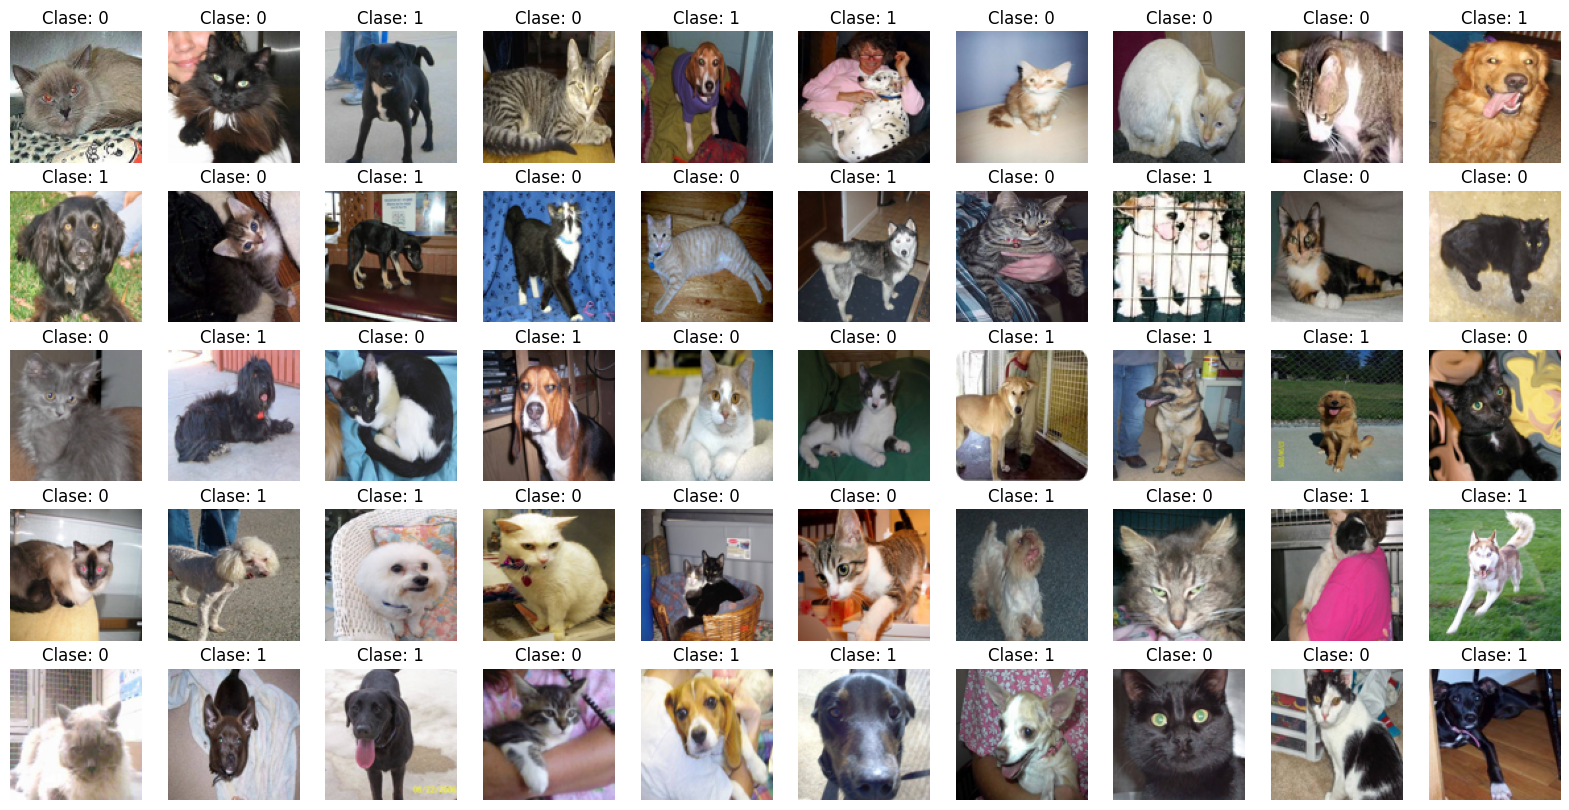

Cargando y mostrando muestras de: validation


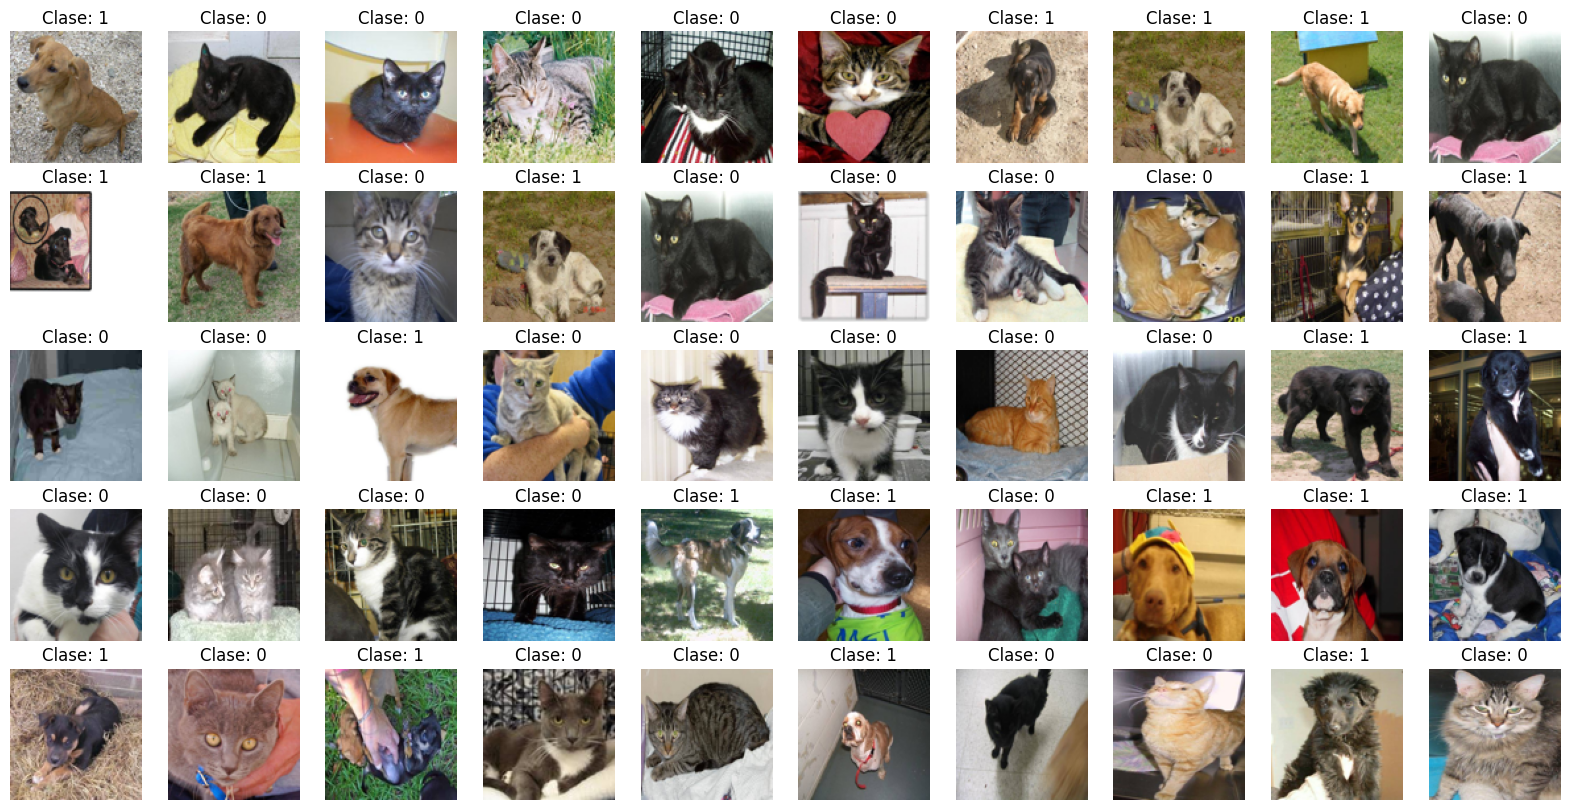

In [70]:
# ============================================================
# Función para mostrar muestras aleatorias de perros y gatos
# ============================================================
def mostrar_muestras_dataset(base_dir, tipo_datos, c=10, r=5):
    print(f"Cargando y mostrando muestras de: {tipo_datos}")
    fig = plt.figure(figsize=(20, 10))
    ruta_datos = os.path.join(base_dir, tipo_datos)
    conjunto_datos = dataset_mascotas(datasets.ImageFolder(root=ruta_datos))

    for i in range(1, c*r + 1):
        idx = torch.randint(len(conjunto_datos), size=(1,)).item()
        img, label = conjunto_datos[idx]
        img = img.resize((100, 100))
        fig.add_subplot(r, c, i)
        plt.title(f"Clase: {label}")
        plt.axis("off")
        plt.imshow(img)
    plt.show()

base_dir = "data/cats_and_dogs_filtered"
mostrar_muestras_dataset(base_dir, 'train')
mostrar_muestras_dataset(base_dir, 'validation')

In [71]:
# ============================================================
# Cálculo de la Media y Desviación Estándar del Dataset
# ============================================================
path_train = os.path.join(base_dir, 'train')
transform_calculo = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])
dataset_calculo = datasets.ImageFolder(root=path_train, transform=transform_calculo)
loader_calculo = DataLoader(dataset_calculo, batch_size=64, shuffle=False, num_workers=4)

media = 0.0
desviacion = 0.0
total_muestras = 0.0
for datos, _ in loader_calculo:
    muestras_lote = datos.size(0)
    datos = datos.view(muestras_lote, datos.size(1), -1)
    media += datos.mean(2).sum(0)
    desviacion += datos.std(2).sum(0)
    total_muestras += muestras_lote
media /= total_muestras
desviacion /= total_muestras
print(f"Media del dataset de imágenes (RGB): {media}")
print(f"Desviación estándar del dataset (RGB): {desviacion}")

Media del dataset de imágenes (RGB): tensor([0.4854, 0.4515, 0.4143])
Desviación estándar del dataset (RGB): tensor([0.2251, 0.2197, 0.2204])


In [72]:
# ============================================================
# Módulo de datos Lightning (ModuloDatosCatsDogs)
# ============================================================
class ModuloDatosCatsDogs(pl.LightningDataModule):
    def __init__(self, data_dir: str, img_size=224, batch_size=200):
        super().__init__()
        self.data_dir = data_dir
        self.img_size = img_size
        self.batch_size = batch_size

        # Transformadas para entrenamiento (con aumentación de datos)
        self.train_transform = transforms.Compose([
            transforms.Resize(size=(self.img_size, self.img_size)),
            transforms.RandomRotation(degrees=10),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize([0.4854, 0.4515, 0.4143], [0.2251, 0.2197, 0.2204])
        ])

        # Transformadas para validación y prueba (sin aumentación)
        self.test_transform = transforms.Compose([
            transforms.Resize(size=(self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.4854, 0.4515, 0.4143], [0.2251, 0.2197, 0.2204])
        ])

    def setup(self, stage=None):
        path_train = os.path.join(self.data_dir, 'train')
        path_test = os.path.join(self.data_dir, 'validation')

        mydataset_train = datasets.ImageFolder(root=path_train)
        mydataset_test = datasets.ImageFolder(root=path_test)
        self.categories = mydataset_test.class_to_idx

        # Instanciar subsets y datasets personalizados
        traindataset = dataset_mascotas(mydataset_train, self.train_transform)
        self.testdataset = dataset_mascotas(mydataset_test, self.test_transform)

        # Partición de entrenamiento (90%) y validación (10%)
        train_size = 0.9
        num_train = len(mydataset_train)
        indices = list(range(num_train))
        split = int(np.floor(train_size * num_train))
        np.random.shuffle(indices)

        self.traindata = torch.utils.data.Subset(traindataset, indices=indices[:split])
        self.validdata = torch.utils.data.Subset(traindataset, indices=indices[split:])

    def train_dataloader(self):
        return DataLoader(self.traindata, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.validdata, batch_size=self.batch_size, shuffle=False)

    def test_dataloader(self):
        return DataLoader(self.testdataset, batch_size=self.batch_size, shuffle=False)

Datos en conjunto de validation:
   Clase dogs: 500 imágenes
   Clase cats: 500 imágenes


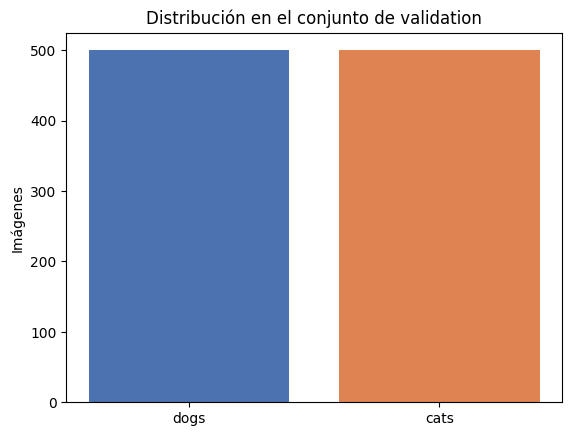

In [73]:
# ============================================================
# Visualizar cantidad de muestras de validación
# ============================================================
def mostrar_tamanio_datos(data_path, tipo_datos):
    data_path = os.path.join(data_path, tipo_datos)
    directorios = [f.path for f in os.scandir(data_path) if f.is_dir()]
    nombres_clases = [os.path.basename(x) for x in directorios]
    cantidades = []
    print(f"Datos en conjunto de {tipo_datos}:")
    for class_path, class_name in zip(directorios, nombres_clases):
        archivos = glob(os.path.join(class_path, "*.jpg"))
        print(f"   Clase {class_name}: {len(archivos)} imágenes")
        cantidades.append(len(archivos))
    plt.bar(nombres_clases, cantidades, color=['#4C72B0', '#DD8452'])
    plt.title(f"Distribución en el conjunto de {tipo_datos}")
    plt.ylabel("Imágenes")
    plt.show()
    return cantidades

cantidades_val = mostrar_tamanio_datos(base_dir, "validation")

In [74]:
# Instanciar y verificar tamaños de lote en el cargador
modulo_datos = ModuloDatosCatsDogs(data_dir=base_dir, img_size=224, batch_size=100)
modulo_datos.setup()
cargador_entrenamiento = modulo_datos.train_dataloader()
for i, (imagenes, etiquetas) in enumerate(cargador_entrenamiento):
    print(f"Lote {i+1}: dimensiones del lote = {imagenes.shape}")
    break

Lote 1: dimensiones del lote = torch.Size([100, 3, 224, 224])


## **4.3 Arquitectura de Red Convolucional Personalizada (RedConvolucionalLightning)**

In [75]:
# ============================================================
# Definición de la arquitectura CNN personalizada usando Lightning
# ============================================================
class RedConvolucionalLightning(pl.LightningModule):
    def __init__(self, num_classes=2, lr=1e-3):
        super().__init__()
        self.num_classes = num_classes
        self.lr = lr

        # Historial de métricas para graficar curvas de aprendizaje
        self.historial_perdida_entrenamiento = []
        self.historial_f1_entrenamiento = []
        self.historial_perdida_validacion = []
        self.historial_f1_validacion = []
        self.perdidas_entrenamiento_lote = []
        self.perdidas_validacion_lote = []

        # Red convolucional personalizada
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)  # Salida: 112x112x64
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2)  # Salida: 56x56x32
        )

        self.adapt = nn.AdaptiveMaxPool2d((10, 10))  # Salida: 10x10x32 (3200 características)
        self.fc = nn.Linear(32 * 10 * 10, self.num_classes)

        self.loss = nn.CrossEntropyLoss()
        self.train_f1 = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")
        self.valid_f1 = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")
        self.test_f1  = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.adapt(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        perdida = self.loss(y_pred, y)
        self.train_f1(torch.argmax(y_pred, dim=1), y)
        self.perdidas_entrenamiento_lote.append(perdida.detach())
        self.log('train_loss', perdida, on_step=False, on_epoch=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True)
        return perdida

    def on_train_epoch_end(self):
        avg_loss = torch.stack(self.perdidas_entrenamiento_lote).mean().item()
        f1 = self.train_f1.compute().item()
        self.historial_perdida_entrenamiento.append(avg_loss)
        self.historial_f1_entrenamiento.append(f1)
        self.perdidas_entrenamiento_lote.clear()
        self.train_f1.reset()
        print(f"Época {self.current_epoch}: train_loss={avg_loss:.4f}, train_f1={f1:.4f}", end=" | ")

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        perdida = self.loss(y_pred, y)
        self.valid_f1(torch.argmax(y_pred, dim=1), y)
        self.perdidas_validacion_lote.append(perdida.detach())
        self.log('val_loss', perdida, on_step=False, on_epoch=True)
        self.log('val_f1', self.valid_f1, on_step=False, on_epoch=True)
        return perdida

    def on_validation_epoch_end(self):
        if not self.perdidas_validacion_lote:
            return
        avg_loss = torch.stack(self.perdidas_validacion_lote).mean().item()
        f1 = self.valid_f1.compute().item()
        self.historial_perdida_validacion.append(avg_loss)
        self.historial_f1_validacion.append(f1)
        self.perdidas_validacion_lote.clear()
        self.valid_f1.reset()
        print(f"val_loss={avg_loss:.4f}, val_f1={f1:.4f}")

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        perdida = self.loss(y_pred, y)
        self.test_f1(torch.argmax(y_pred, dim=1), y)
        self.log('test_loss', perdida)
        self.log('test_f1', self.test_f1)
        return perdida

    def on_test_epoch_end(self):
        self.log('avg_test_f1', self.test_f1.compute())

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

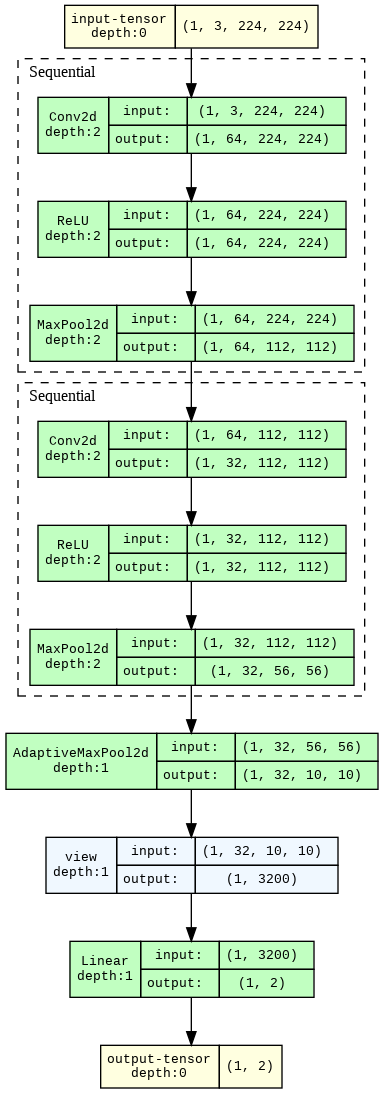

In [76]:
# Graficar el flujo del modelo RedConvolucionalLightning
grafo_lightning = draw_graph(RedConvolucionalLightning(), input_size=(1, 3, 224, 224), expand_nested=True)
grafo_lightning.visual_graph

In [77]:
# ============================================================
# Definición de la función genérica de entrenamiento de Lightning
# ============================================================
seed_everything(42, workers=False)

def proceso_entrenamiento(modelo, num_epocas, img_size, batch_size, data_dir):
    callback_model_checkpoint = ModelCheckpoint(
        filename='{epoch}-{val_loss:.3f}',
        monitor='val_loss',
        mode='min',
        dirpath="results"
    )
    dm = ModuloDatosCatsDogs(data_dir=data_dir, img_size=img_size, batch_size=batch_size)
    trainer = Trainer(
        fast_dev_run=False,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        log_every_n_steps=5,
        max_epochs=num_epocas,
        callbacks=[callback_model_checkpoint],
        enable_progress_bar=False
    )
    trainer.fit(modelo, dm)
    trainer.test(modelo, dm)
    return modelo, callback_model_checkpoint.best_model_path

INFO:lightning_fabric.utilities.seed:Seed set to 42


In [78]:
# ============================================================
# Entrenamiento del modelo personalizado de Cats & Dogs
# ============================================================
gc.collect()
torch.cuda.empty_cache()

# Configuración local de hiperparámetros
num_clases = 2
num_epocas = 10
batch_size = 100
img_size = 224
lr = 1e-3
data_dir = "data/cats_and_dogs_filtered"

modelo_cnn_lightning = RedConvolucionalLightning(num_clases, lr)
modelo_cnn_lightning, best_model_path = proceso_entrenamiento(
    modelo_cnn_lightning, num_epocas, img_size, batch_size, data_dir
)
print(f"Mejor modelo personalizado guardado en: {best_model_path}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv1    │ Sequential        │  4.9 K │ train │     0 │
│ 1 │ conv2    │ Sequential        │ 51.2 K │ train │     0 │
│ 2 │ adapt    │ AdaptiveMaxPool2d │      0 │ train │     0 │
│ 3 │ fc       │ Linear            │  6.4 K │ train │     0 │
│ 4 │ loss     │ CrossEntropyLoss  │      0 │ train │     0 │
│ 5 │ train_f1 │ MulticlassF1Score │      0 │ train │     0 │
│ 6 │ valid_f1 │ MulticlassF1Score │      0 │ train │     0 │
│ 7 │ test_f1  │ MulticlassF1Score │      0 │ train │     0 │
└───┴──────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 62.5 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 62.5 K                                                                                               
Total estimated model params size (MB): 0.250                                                                      
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

val_loss=0.7008, val_f1=0.4812
val_loss=0.6890, val_f1=0.5459
Época 0: train_loss=0.7384, train_f1=0.4836 | val_loss=0.6806, val_f1=0.4838
Época 1: train_loss=0.6895, train_f1=0.5420 | val_loss=0.6643, val_f1=0.6519
Época 2: train_loss=0.6837, train_f1=0.5719 | val_loss=0.6180, val_f1=0.6779
Época 3: train_loss=0.6672, train_f1=0.6133 | val_loss=0.5968, val_f1=0.7152
Época 4: train_loss=0.6506, train_f1=0.6368 | val_loss=0.5991, val_f1=0.6577
Época 5: train_loss=0.6306, train_f1=0.6629 | val_loss=0.5790, val_f1=0.6774
Época 6: train_loss=0.6129, train_f1=0.6711 | val_loss=0.5628, val_f1=0.7141
Época 7: train_loss=0.5794, train_f1=0.6978 | val_loss=0.5351, val_f1=0.7246
Época 8: train_loss=0.5808, train_f1=0.7011 | 

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


val_loss=0.5278, val_f1=0.7230
Época 9: train_loss=0.5550, train_f1=0.7141 | 

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        avg_test_f1        │    0.6458239555358887     │
│          test_f1          │    0.6458239555358887     │
│         test_loss         │    0.6030340790748596     │
└───────────────────────────┴───────────────────────────┘

Mejor modelo personalizado guardado en: /content/results/epoch=9-val_loss=0.528.ckpt


## **4.5 Curvas de Aprendizaje del Modelo Personalizado**

Graficamos el progreso de la pérdida y la exactitud para entrenamiento y validación por época.

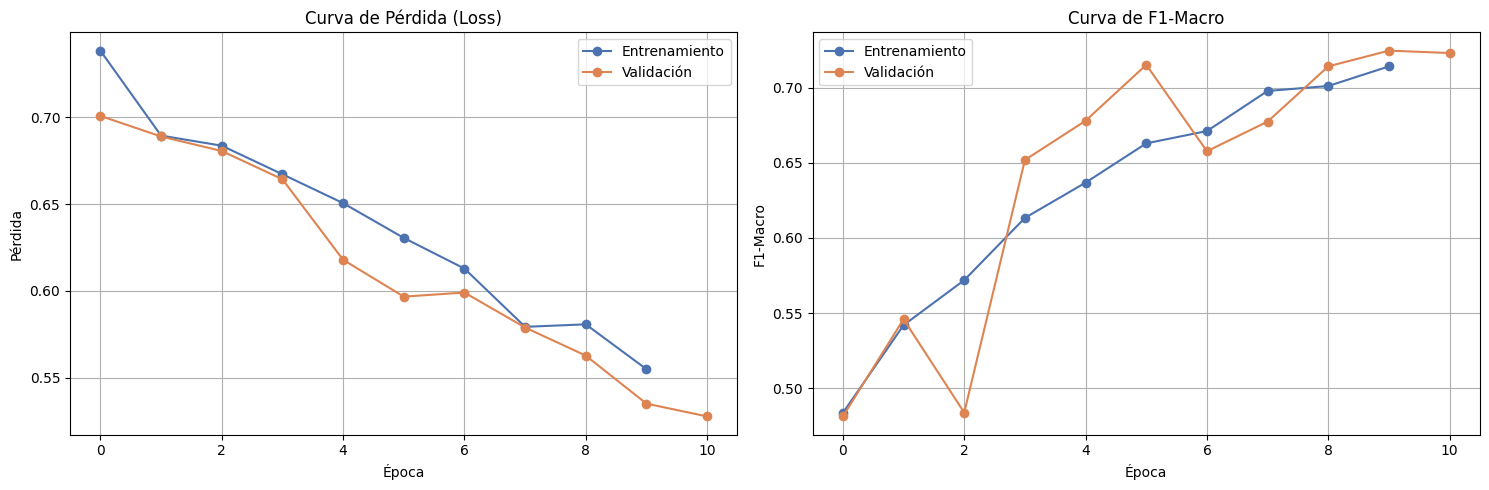

In [79]:
# ============================================================
# Función para graficar las curvas de aprendizaje
# ============================================================
def graficar_curvas_aprendizaje(modelo):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Pérdida (Loss)
    ax1.plot(modelo.historial_perdida_entrenamiento, label='Entrenamiento', color='#4C72B0', marker='o')
    ax1.plot(modelo.historial_perdida_validacion, label='Validación', color='#DD8452', marker='o')
    ax1.set_title('Curva de Pérdida (Loss)')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Pérdida')
    ax1.legend()
    ax1.grid(True)
    
    # Exactitud (Accuracy)
    ax2.plot(modelo.historial_f1_entrenamiento, label='Entrenamiento', color='#4C72B0', marker='o')
    ax2.plot(modelo.historial_f1_validacion, label='Validación', color='#DD8452', marker='o')
    ax2.set_title('Curva de F1-Macro')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('F1-Macro')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

graficar_curvas_aprendizaje(modelo_cnn_lightning)

## **4.6 Matriz de Confusión y Métricas de Rendimiento**

Evaluamos el modelo cargando los pesos del mejor checkpoint y generamos métricas detalladas.

In [80]:
# ============================================================
# Función para recopilar predicciones completas en prueba
# ============================================================
@torch.no_grad()
def obtener_todas_predicciones(modelo, loader):
    modelo.eval()
    predicciones_totales = torch.tensor([]).to(device)
    etiquetas_totales = torch.tensor([]).to(device)

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        preds = modelo(x)
        predicciones_totales = torch.cat((predicciones_totales, preds), dim=0)
        etiquetas_totales = torch.cat((etiquetas_totales, y), dim=0)
    return predicciones_totales, etiquetas_totales

In [81]:
# ============================================================
# Evaluación y Reporte de Clasificación del Modelo Convolucional
# ============================================================
modelo_cargado = RedConvolucionalLightning.load_from_checkpoint(best_model_path, num_classes=num_clases, lr=lr)

modulo_datos_eval = ModuloDatosCatsDogs(data_dir=data_dir, img_size=img_size, batch_size=1)
modulo_datos_eval.setup()
cargador_test = modulo_datos_eval.test_dataloader()

predicciones, etiquetas = obtener_todas_predicciones(modelo_cargado.to(device), cargador_test)
y_verdadero = etiquetas.cpu()
y_predicho = predicciones.argmax(dim=1).cpu()
nombres_clases = list(modulo_datos_eval.categories.keys())

matriz_conf = confusion_matrix(y_verdadero, y_predicho)
total_por_clase = np.sum(matriz_conf, axis=1)
matriz_conf_norm = np.divide(matriz_conf, np.reshape(total_por_clase, (-1, 1)))

print("Reporte de Clasificación:")
print(classification_report(y_verdadero, y_predicho, target_names=nombres_clases, zero_division=0))

Reporte de Clasificación:
              precision    recall  f1-score   support

        cats       0.77      0.45      0.57       500
        dogs       0.61      0.87      0.72       500

    accuracy                           0.66      1000
   macro avg       0.69      0.66      0.65      1000
weighted avg       0.69      0.66      0.65      1000



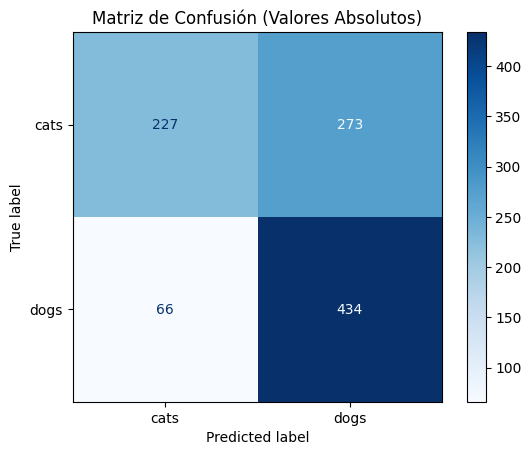

In [82]:
# Mostrar matriz de confusión absoluta
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_conf, display_labels=nombres_clases)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión (Valores Absolutos)")
plt.show()

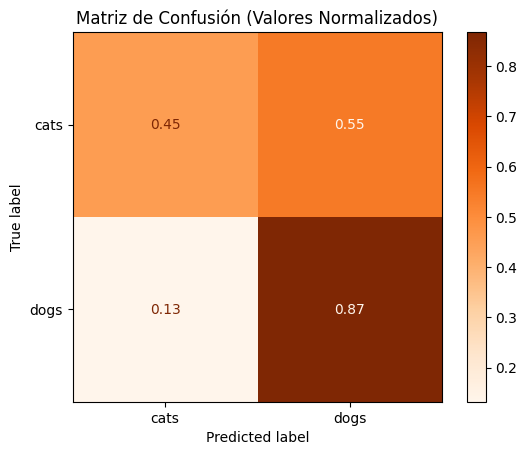

In [83]:
# Mostrar matriz de confusión normalizada
disp_norm = ConfusionMatrixDisplay(confusion_matrix=matriz_conf_norm, display_labels=nombres_clases)
disp_norm.plot(cmap='Oranges')
plt.title("Matriz de Confusión (Valores Normalizados)")
plt.show()

# **5. Transfer Learning con ResNet18**

La transferencia de aprendizaje (*Transfer Learning*) nos permite tomar un modelo muy robusto preentrenado en millones de imágenes de ImageNet (como ResNet18) y adaptarlo para clasificar perros y gatos. Al conservar la extracción de características genéricas aprendidas, la red aprende la nueva tarea rápidamente con pocos datos y altísima precisión.

In [84]:
# ============================================================
# Definición del Modelo ResNet18 Preentrenado en Lightning
# ============================================================
class ModeloResNet18(pl.LightningModule):
    def __init__(self, num_classes=2, lr=1e-3):
        super().__init__()
        self.num_classes = num_classes
        self.lr = lr

        # Historial de métricas para graficar curvas de aprendizaje
        self.historial_perdida_entrenamiento = []
        self.historial_f1_entrenamiento = []
        self.historial_perdida_validacion = []
        self.historial_f1_validacion = []
        self.perdidas_entrenamiento_lote = []
        self.perdidas_validacion_lote = []

        # Cargar ResNet18 preentrenado con pesos por defecto de ImageNet
        self.resnet = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
        
        # Reemplazar la capa fc para adaptarla a 2 clases de salida (perros vs gatos)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, self.num_classes)

        self.loss = nn.CrossEntropyLoss()
        self.train_f1 = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")
        self.valid_f1 = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")
        self.test_f1  = F1Score(task="multiclass", num_classes=self.num_classes, average="macro")

    def forward(self, x):
        return self.resnet(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        perdida = self.loss(y_pred, y)
        self.train_f1(torch.argmax(y_pred, dim=1), y)
        self.perdidas_entrenamiento_lote.append(perdida.detach())
        self.log('train_loss', perdida, on_step=False, on_epoch=True)
        self.log('train_f1', self.train_f1, on_step=False, on_epoch=True)
        return perdida

    def on_train_epoch_end(self):
        avg_loss = torch.stack(self.perdidas_entrenamiento_lote).mean().item()
        f1 = self.train_f1.compute().item()
        self.historial_perdida_entrenamiento.append(avg_loss)
        self.historial_f1_entrenamiento.append(f1)
        self.perdidas_entrenamiento_lote.clear()
        self.train_f1.reset()
        print(f"Época {self.current_epoch}: train_loss={avg_loss:.4f}, train_f1={f1:.4f}", end=" | ")

    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        perdida = self.loss(y_pred, y)
        self.valid_f1(torch.argmax(y_pred, dim=1), y)
        self.perdidas_validacion_lote.append(perdida.detach())
        self.log('val_loss', perdida, on_step=False, on_epoch=True)
        self.log('val_f1', self.valid_f1, on_step=False, on_epoch=True)
        return perdida

    def on_validation_epoch_end(self):
        if not self.perdidas_validacion_lote:
            return
        avg_loss = torch.stack(self.perdidas_validacion_lote).mean().item()
        f1 = self.valid_f1.compute().item()
        self.historial_perdida_validacion.append(avg_loss)
        self.historial_f1_validacion.append(f1)
        self.perdidas_validacion_lote.clear()
        self.valid_f1.reset()
        print(f"val_loss={avg_loss:.4f}, val_f1={f1:.4f}")

    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self(x)
        perdida = self.loss(y_pred, y)
        self.test_f1(torch.argmax(y_pred, dim=1), y)
        self.log('test_loss', perdida)
        self.log('test_f1', self.test_f1)
        return perdida

    def on_test_epoch_end(self):
        self.log('avg_test_f1', self.test_f1.compute())

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.lr)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 147MB/s]


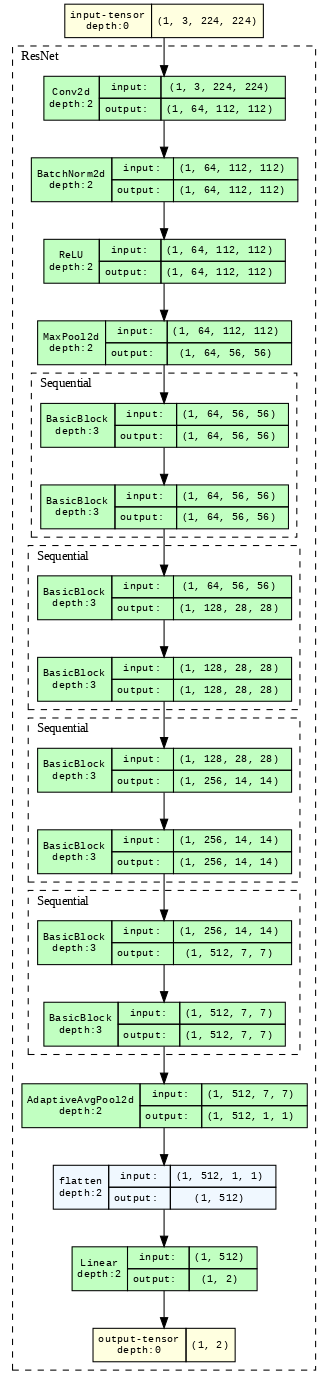

In [85]:
# Graficar el grafo del flujo de ResNet18
grafo_resnet = draw_graph(ModeloResNet18(), input_size=(1, 3, 224, 224), expand_nested=True)
grafo_resnet.visual_graph

In [86]:
# ============================================================
# Entrenamiento del modelo ResNet18 (Transfer Learning)
# ============================================================
gc.collect()
torch.cuda.empty_cache()

# Ajustamos hiperparámetros específicos para transferencia de aprendizaje
lr_resnet = 1e-4      # Tasa de aprendizaje más baja para no arruinar los pesos preentrenados
num_epocas_resnet = 5 # ResNet converge mucho más rápido, 5 épocas son suficientes

modelo_resnet = ModeloResNet18(num_classes=num_clases, lr=lr_resnet)
modelo_resnet, best_model_path_resnet = proceso_entrenamiento(
    modelo_resnet, num_epocas_resnet, img_size, batch_size, data_dir
)
print(f"Mejor modelo ResNet18 guardado en: {best_model_path_resnet}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name     ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ resnet   │ ResNet            │ 11.2 M │ train │     0 │
│ 1 │ loss     │ CrossEntropyLoss  │      0 │ train │     0 │
│ 2 │ train_f1 │ MulticlassF1Score │      0 │ train │     0 │
│ 3 │ valid_f1 │ MulticlassF1Score │      0 │ train │     0 │
│ 4 │ test_f1  │ MulticlassF1Score │      0 │ train │     0 │
└───┴──────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 11.2 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 11.2 M                                                                                               
Total estimated model params size (MB): 44.710                                                                     
Modules in train mode: 72                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

val_loss=0.8783, val_f1=0.3421
val_loss=0.0397, val_f1=0.9850
Época 0: train_loss=0.1897, train_f1=0.9121 | val_loss=0.0381, val_f1=0.9850
Época 1: train_loss=0.0319, train_f1=0.9900 | val_loss=0.0582, val_f1=0.9799
Época 2: train_loss=0.0154, train_f1=0.9956 | val_loss=0.0611, val_f1=0.9749
Época 3: train_loss=0.0125, train_f1=0.9967 | 

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=5` reached.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


val_loss=0.0460, val_f1=0.9850
Época 4: train_loss=0.0043, train_f1=0.9994 | 

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        avg_test_f1        │    0.9869999885559082     │
│          test_f1          │    0.9869999885559082     │
│         test_loss         │   0.027249053120613098    │
└───────────────────────────┴───────────────────────────┘

Mejor modelo ResNet18 guardado en: /content/results/epoch=1-val_loss=0.038.ckpt


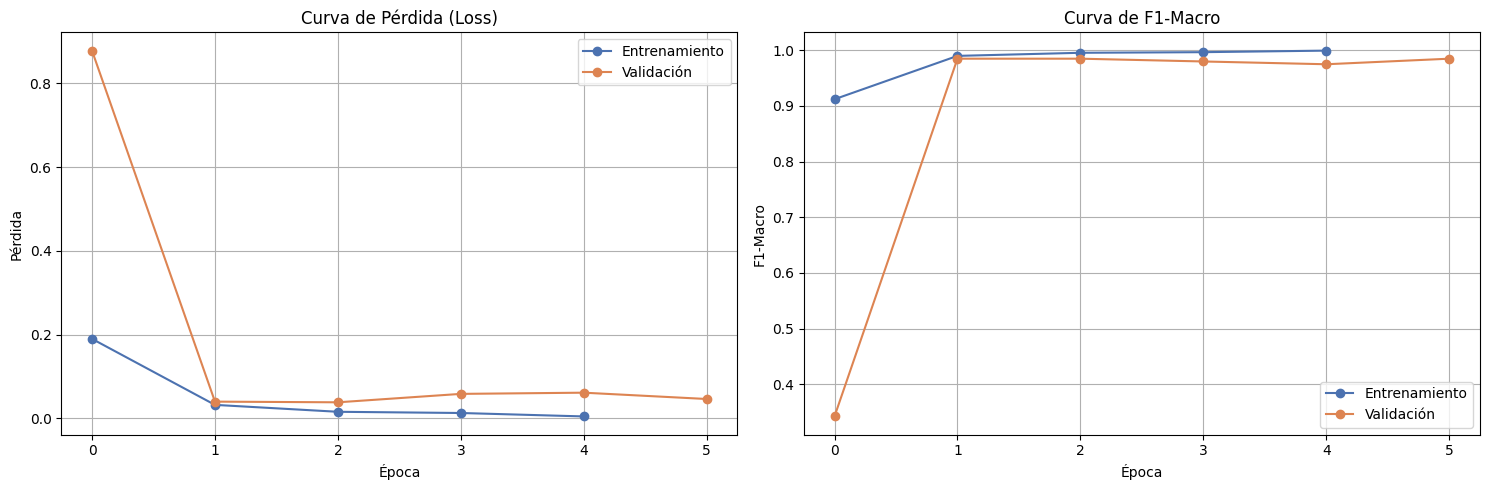

In [87]:
# Graficar las curvas de aprendizaje de ResNet18
graficar_curvas_aprendizaje(modelo_resnet)

In [88]:
# ============================================================
# Evaluación y Reporte de Clasificación del Modelo ResNet18
# ============================================================
modelo_resnet_cargado = ModeloResNet18.load_from_checkpoint(best_model_path_resnet, num_classes=num_clases, lr=lr_resnet)
all_preds_resnet, all_labels_resnet = obtener_todas_predicciones(modelo_resnet_cargado.to(device), cargador_test)

y_true_resnet = all_labels_resnet.cpu()
y_pred_resnet = all_preds_resnet.argmax(dim=1).cpu()

matriz_conf_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)
total_por_clase_resnet = np.sum(matriz_conf_resnet, axis=1)
matriz_conf_norm_resnet = np.divide(matriz_conf_resnet, np.reshape(total_por_clase_resnet, (-1, 1)))

print("Reporte de Clasificación (ResNet18):")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=nombres_clases, zero_division=0))

Reporte de Clasificación (ResNet18):
              precision    recall  f1-score   support

        cats       0.97      0.99      0.98       500
        dogs       0.99      0.97      0.98       500

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



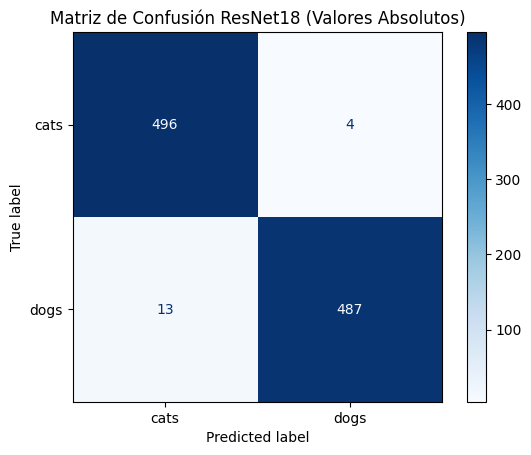

In [89]:
# Mostrar matriz de confusión absoluta para ResNet18
disp_res = ConfusionMatrixDisplay(confusion_matrix=matriz_conf_resnet, display_labels=nombres_clases)
disp_res.plot(cmap='Blues')
plt.title("Matriz de Confusión ResNet18 (Valores Absolutos)")
plt.show()

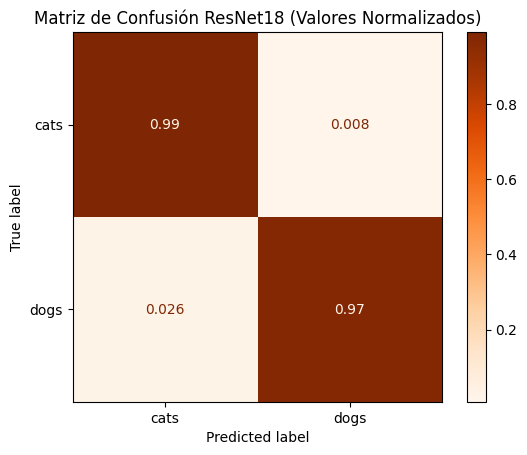

In [90]:
# Mostrar matriz de confusión normalizada para ResNet18
disp_res_norm = ConfusionMatrixDisplay(confusion_matrix=matriz_conf_norm_resnet, display_labels=nombres_clases)
disp_res_norm.plot(cmap='Oranges')
plt.title("Matriz de Confusión ResNet18 (Valores Normalizados)")
plt.show()